## 2. Develop the sentiment classification model using only foundational NLP concepts. Use this dataset. Download the dataset and perform:
- Use only text and sentiment columns
- Text preprocessing
- Tokenization
- Text Representations
- Train a logistic regression
- Evaluate the model


P.S. Use different text representations like first use BoW and train and evaluate the model. Again, use TF-IDF, train and evaluate the model. Again use word embeddings (Word2Vec, Glove), train and evaluate the model.


In [1]:
# Install Kaggle API
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Set up Kaggle API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d abhi8923shriv/sentiment-analysis-dataset

# Unzip the dataset
!unzip sentiment-analysis-dataset.zip

# List files
!ls

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset
License(s): CC0-1.0
  0% 0.00/54.4M [00:00<?, ?B/s]
100% 54.4M/54.4M [00:00<00:00, 987MB/s]
Archive:  sentiment-analysis-dataset.zip
  inflating: test.csv                
  inflating: testdata.manual.2009.06.14.csv  
  inflating: train.csv               
  inflating: training.1600000.processed.noemoticon.csv  
kaggle.json			testdata.manual.2009.06.14.csv
sample_data			train.csv
sentiment-analysis-dataset.zip	training.1600000.processed.noemoticon.csv
test.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
train_df = pd.read_csv('/content/train.csv', encoding='latin-1')
train_df

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26
...,...,...,...,...,...,...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,night,31-45,Ghana,31072940,227540.0,137
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,morning,46-60,Greece,10423054,128900.0,81
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,noon,60-70,Grenada,112523,340.0,331
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive,night,70-100,Guatemala,17915568,107160.0,167


In [4]:
train_df=train_df[['text','sentiment']]

In [5]:
train_df.head(2)

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative


In [6]:
test_df=pd.read_csv('/content/test.csv', encoding='latin-1')
test_df

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0
...,...,...,...,...,...,...,...,...,...
4810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
test_df=test_df[['text','sentiment']]
test_df.head(2)

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive


In [8]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
train_df['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


In [10]:
# Check for missing values
print("Missing values in train_df:", train_df['text'].isna().sum())
print("Missing values in test_df:", test_df['text'].isna().sum())

Missing values in train_df: 1
Missing values in test_df: 1281


In [11]:
# Drop rows with missing text (if few) or fill with empty string
train_df = train_df.dropna(subset=['text'])  # Option 1: Remove NaN rows
test_df = test_df.dropna(subset=['text'])

# Check for missing values
print("Missing values in train_df:", train_df['text'].isna().sum())
print("Missing values in test_df:", test_df['text'].isna().sum())

Missing values in train_df: 0
Missing values in test_df: 0


In [12]:
# Preprocessing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special chars & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [13]:

# Apply preprocessing
train_df['cleaned_text'] = train_df['text'].apply(preprocess_text)
test_df['cleaned_text'] = test_df['text'].apply(preprocess_text)

In [14]:
train_df

,text,sentiment,cleaned_text
0,"I`d have responded, if I were going",neutral,id responded going
1,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad miss san diego
2,my boss is bullying me...,negative,bos bullying
3,what interview! leave me alone,negative,interview leave alone
4,"Sons of ****, why couldn`t they put them on t...",negative,son couldnt put release already bought
...,...,...,...
27476,wish we could come see u on Denver husband l...,negative,wish could come see u denver husband lost job ...
27477,I`ve wondered about rake to. The client has ...,negative,ive wondered rake client made clear net dont f...
27478,Yay good for both of you. Enjoy the break - y...,positive,yay good enjoy break probably need hectic week...
27479,But it was worth it ****.,positive,worth


In [15]:
test_df

,text,sentiment,cleaned_text
0,Last session of the day http://twitpic.com/67ezh,neutral,last session day httptwitpiccomezh
1,Shanghai is also really exciting (precisely -...,positive,shanghai also really exciting precisely skyscr...
2,"Recession hit Veronique Branquinho, she has to...",negative,recession hit veronique branquinho quit compan...
3,happy bday!,positive,happy bday
4,http://twitpic.com/4w75p - I like it!!,positive,httptwitpiccomwp like
...,...,...,...
3529,"its at 3 am, im very tired but i can`t sleep ...",negative,im tired cant sleep try
3530,All alone in this old house again. Thanks for...,positive,alone old house thanks net keep alive kicking ...
3531,I know what you mean. My little dog is sinkin...,negative,know mean little dog sinking depression want m...
3532,_sutra what is your next youtube video gonna b...,positive,sutra next youtube video gon na love video


In [16]:
X_train, y_train = train_df['cleaned_text'], train_df['sentiment']
X_test, y_test = test_df['cleaned_text'], test_df['sentiment']

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


BoW Accuracy: 0.6994906621392191

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.65      0.67      1001
     Neutral       0.64      0.73      0.68      1430
    Positive       0.79      0.71      0.75      1103

    accuracy                           0.70      3534
   macro avg       0.71      0.70      0.70      3534
weighted avg       0.71      0.70      0.70      3534



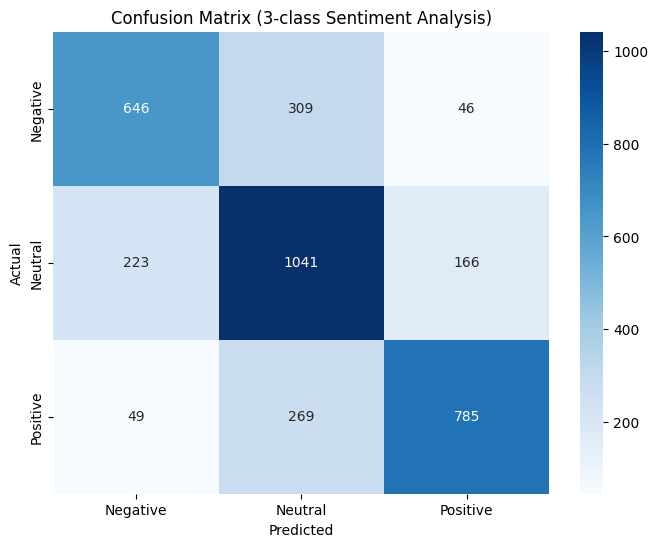


Test Set Class Distribution:
sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# BoW Vectorization
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

# Train Logistic Regression (multi_class='multinomial' for 3 classes)
model_bow = LogisticRegression(max_iter=1000, multi_class='multinomial')
model_bow.fit(X_train_bow, y_train)

# Evaluate
y_pred_bow = model_bow.predict(X_test_bow)

# 1. Print Accuracy and Classification Report
print("BoW Accuracy:", accuracy_score(y_test, y_pred_bow))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bow,
                           target_names=['Negative', 'Neutral', 'Positive']))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (3-class Sentiment Analysis)')
plt.show()

# 3. Class Distribution Check (important for imbalanced datasets)
print("\nTest Set Class Distribution:")
print(pd.Series(y_test).value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


TF-IDF Accuracy: 0.699

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.71      0.69      1001
     Neutral       0.67      0.66      0.66      1430
    Positive       0.78      0.74      0.76      1103

    accuracy                           0.70      3534
   macro avg       0.70      0.70      0.70      3534
weighted avg       0.70      0.70      0.70      3534



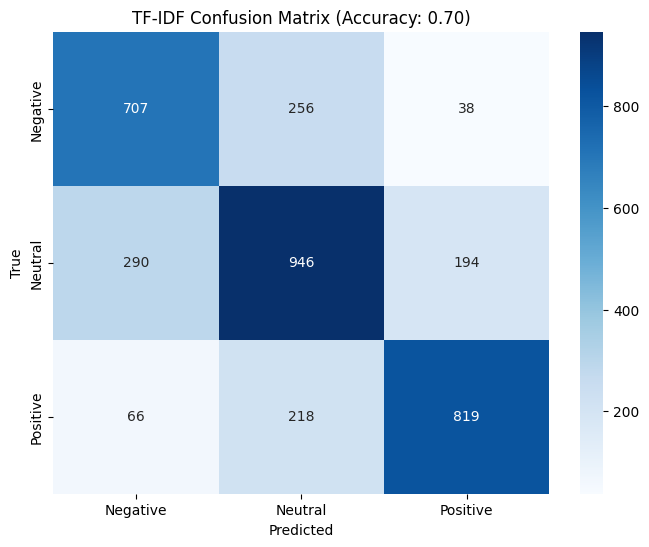


Class prediction probabilities sample:
   Negative   Neutral  Positive
0  0.184024  0.496734  0.319242
1  0.057683  0.073537  0.868780
2  0.636009  0.341074  0.022917

Top 5 features per class:
Negative: sorry, suck, hate, miss, sad
Neutral: guitar, moro, training, werent, hows
Positive: good, great, awesome, thanks, love


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# TF-IDF Vectorization
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression for multi-class
model_tfidf = LogisticRegression(max_iter=1000,
                                multi_class='multinomial',
                                solver='lbfgs',
                                class_weight='balanced')  # Handles class imbalance
model_tfidf.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# 1. Print Metrics
print("TF-IDF Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred_tfidf)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf,
                          target_names=['Negative', 'Neutral', 'Positive']))

# 2. Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_tfidf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('TF-IDF Confusion Matrix (Accuracy: {:.2f})'.format(accuracy_score(y_test, y_pred_tfidf)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 3. Class Probabilities (for deeper analysis)
probabilities = model_tfidf.predict_proba(X_test_tfidf)
print("\nClass prediction probabilities sample:")
print(pd.DataFrame(probabilities,
                  columns=['Negative', 'Neutral', 'Positive']).head(3))

# 4. Most Important Features
feature_names = tfidf.get_feature_names_out()
coefs = model_tfidf.coef_

print("\nTop 5 features per class:")
for i, class_name in enumerate(['Negative', 'Neutral', 'Positive']):
    top5 = np.argsort(coefs[i])[-5:]
    print(f"{class_name}: {', '.join(feature_names[top5])}")

Each tuple is an ngram_range passed to TfidfVectorizer:

- (1,1): Unigrams (single words)

- (1,2): Unigrams + Bigrams

- (1,3): Unigrams + Bigrams + Trigrams

- (2,2): Only Bigrams

- (2,3): Bigrams + Trigrams

## 🔹 What is an n-gram?

An **n-gram** is a contiguous sequence of **n words** from a text. It's used in NLP to capture word context and patterns.

---

### 📚 Examples

Let’s take a sentence:

> `"I love machine learning"`

Here's how different n-grams are formed:

| n-gram Type | `ngram_range` | Output |
|-------------|---------------|--------|
| **Unigrams** | `(1, 1)` | `['I', 'love', 'machine', 'learning']` |
| **Bigrams**  | `(2, 2)` | `['I love', 'love machine', 'machine learning']` |
| **Trigrams** | `(3, 3)` | `['I love machine', 'love machine learning']` |
| **1 to 2-gram** | `(1, 2)` | Unigrams + Bigrams |
| **1 to 3-gram** | `(1, 3)` | Unigrams + Bigrams + Trigrams |
| **2 to 3-gram** | `(2, 3)` | Bigrams + Trigrams |

---

### ✅ Why Use n-grams?

| n-gram | Captures | Example |
|--------|----------|---------|
| **Unigram** | Individual words | `"good"`, `"bad"` |
| **Bigram** | Word pairs / short context | `"not good"`, `"very bad"` |
| **Trigram** | Phrase-level context | `"not at all"`, `"really very good"` |

**➡ Higher n-gram = More context**, but also more features, which can increase sparsity and computation cost.



===== TF-IDF with ngram_range=(1, 1) =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.699
Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.71      0.69      1001
     Neutral       0.67      0.66      0.66      1430
    Positive       0.78      0.74      0.76      1103

    accuracy                           0.70      3534
   macro avg       0.70      0.70      0.70      3534
weighted avg       0.70      0.70      0.70      3534



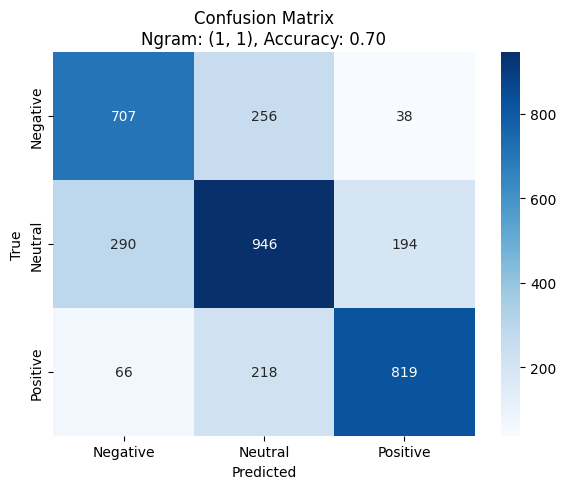

Top 5 features per class:
Negative: sorry, suck, hate, miss, sad
Neutral: guitar, moro, training, werent, hows
Positive: good, great, awesome, thanks, love

===== TF-IDF with ngram_range=(1, 2) =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.697
Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.71      0.68      1001
     Neutral       0.68      0.63      0.66      1430
    Positive       0.76      0.77      0.76      1103

    accuracy                           0.70      3534
   macro avg       0.70      0.70      0.70      3534
weighted avg       0.70      0.70      0.70      3534



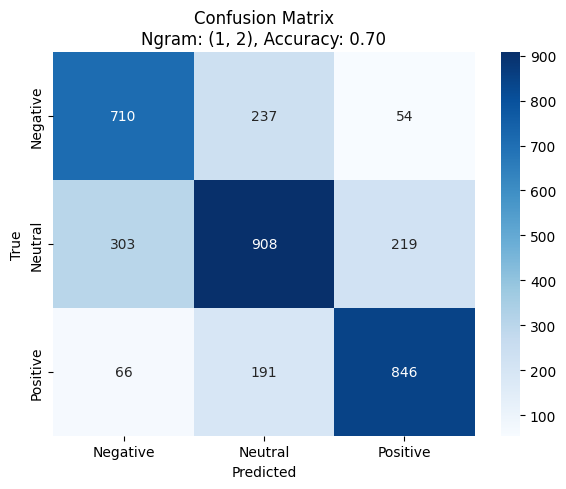

Top 5 features per class:
Negative: sorry, suck, hate, miss, sad
Neutral: nope, goin, morning, watching, hows
Positive: awesome, good, great, thanks, love

===== TF-IDF with ngram_range=(1, 3) =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.698
Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.71      0.69      1001
     Neutral       0.68      0.63      0.66      1430
    Positive       0.74      0.77      0.76      1103

    accuracy                           0.70      3534
   macro avg       0.70      0.70      0.70      3534
weighted avg       0.70      0.70      0.70      3534



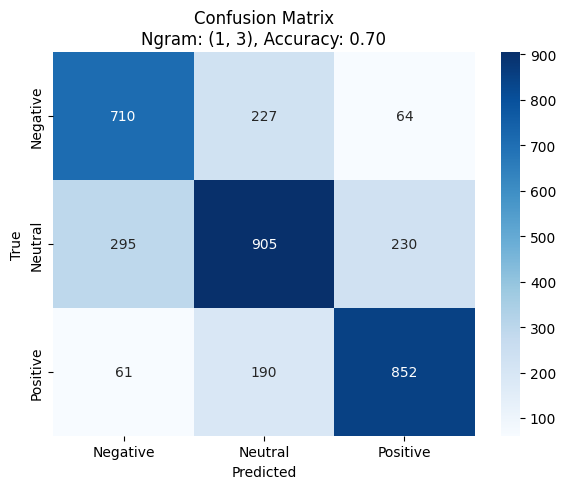

Top 5 features per class:
Negative: sorry, suck, hate, miss, sad
Neutral: lol, yeah, morning, watching, hows
Positive: awesome, great, good, thanks, love

===== TF-IDF with ngram_range=(2, 2) =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.534
Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.41      0.46      1001
     Neutral       0.49      0.66      0.56      1430
    Positive       0.65      0.49      0.56      1103

    accuracy                           0.53      3534
   macro avg       0.55      0.52      0.53      3534
weighted avg       0.55      0.53      0.53      3534



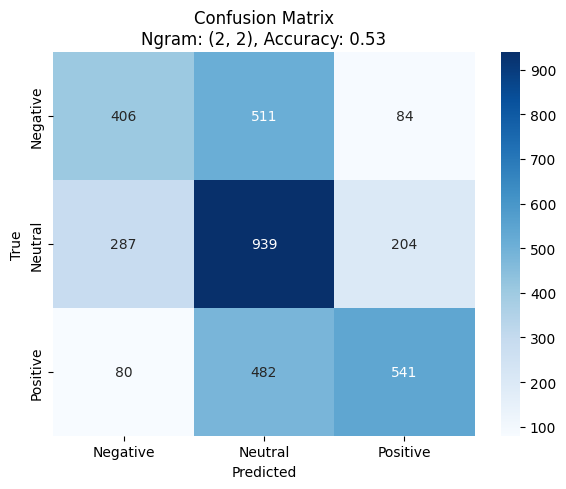

Top 5 features per class:
Negative: im bored, im sad, feel like, dont like, im sorry
Neutral: could get, work work, next week, day till, dont know
Positive: happy birthday, good luck, good morning, mother day, happy mother

===== TF-IDF with ngram_range=(2, 3) =====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.540
Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.40      0.46      1001
     Neutral       0.49      0.69      0.57      1430
    Positive       0.67      0.48      0.56      1103

    accuracy                           0.54      3534
   macro avg       0.57      0.52      0.53      3534
weighted avg       0.56      0.54      0.54      3534



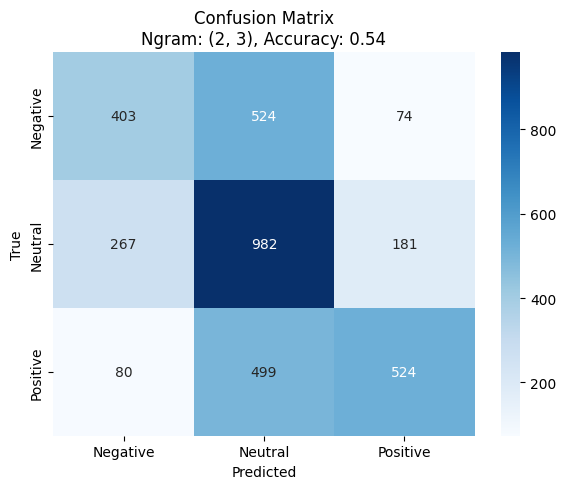

Top 5 features per class:
Negative: sorry hear, im sad, dont like, feel like, im sorry
Neutral: work work, back home, day till, next week, dont know
Positive: happy mother day, happy mother, good luck, mother day, good morning


In [19]:
import numpy as np

ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2), (2, 3)]

for ngram in ngram_ranges:
    print(f"\n===== TF-IDF with ngram_range={ngram} =====")

    # 1. Vectorization
    tfidf = TfidfVectorizer(ngram_range=ngram)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # 2. Train Logistic Regression
    model_tfidf = LogisticRegression(max_iter=1000,
                                     multi_class='multinomial',
                                     solver='lbfgs',
                                     class_weight='balanced')
    model_tfidf.fit(X_train_tfidf, y_train)

    # 3. Evaluate
    y_pred = model_tfidf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    # 4. Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix\nNgram: {ngram}, Accuracy: {acc:.2f}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    # 5. Most important features per class
    feature_names = tfidf.get_feature_names_out()
    coefs = model_tfidf.coef_
    print("Top 5 features per class:")
    for i, class_name in enumerate(['Negative', 'Neutral', 'Positive']):
        top5 = np.argsort(coefs[i])[-5:]
        print(f"{class_name}: {', '.join(feature_names[top5])}")


In [20]:
!pip install --upgrade numpy gensim --force-reinstall


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation:

## 🧠 Word2Vec Explained

**Word2Vec** is a technique that represents words as **dense vectors** such that words with similar meaning have similar vector representations.

---

### 🔹 Why Word2Vec?

Unlike TF-IDF or one-hot encoding, Word2Vec captures **semantic relationships** and **context** of words.

---

### ⚙️ How it Works

It uses a shallow neural network with two main models:

| Model | Description | Example |
|-------|-------------|---------|
| **CBOW** (Continuous Bag of Words) | Predicts a word from surrounding context | `"the cat ___ on the mat"` |
| **Skip-gram** | Predicts surrounding context words from a word | Given `"cat"` → predict `"the"`, `"sat"` |

---

### 📍 Example Insight

> `"king" - "man" + "woman"` ≈ `"queen"`

This shows that Word2Vec understands gender relationships via vector arithmetic.

---

### ✅ Benefits

- Captures semantic similarity
- Useful for clustering, classification, etc.
- Enables arithmetic on words (e.g., analogies)

---

### 🧪 Example Code

```python
from gensim.models import Word2Vec

# Tokenized sentences
sentences = [["i", "love", "machine", "learning"],
             ["word2vec", "is", "awesome"]]

# Train Word2Vec
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=1)

# Get word vector
vector = model.wv['learning']


In [21]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tokenize Text Data
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# 2. Train Word2Vec Model
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4)

# 3. Function to Average Word Vectors
def average_word_vectors(tokens_list, model, vector_size):
    features = []
    for tokens in tokens_list:
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        if vectors:
            avg_vector = np.mean(vectors, axis=0)
        else:
            avg_vector = np.zeros(vector_size)
        features.append(avg_vector)
    return np.array(features)

# 4. Get Vector Representations
X_train_w2v = average_word_vectors(X_train_tokens, w2v_model, 100)
X_test_w2v = average_word_vectors(X_test_tokens, w2v_model, 100)

# 5. Train Logistic Regression
model_w2v = LogisticRegression(max_iter=1000,
                               multi_class='multinomial',
                               solver='lbfgs',
                               class_weight='balanced')
model_w2v.fit(X_train_w2v, y_train)

# 6. Predict
y_pred_w2v = model_w2v.predict(X_test_w2v)

# 7. Evaluation
print("Word2Vec Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred_w2v)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_w2v,
                            target_names=['Negative', 'Neutral', 'Positive']))

# 8. Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_w2v)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Word2Vec Confusion Matrix (Accuracy: {:.2f})'.format(accuracy_score(y_test, y_pred_w2v)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 9. Class Prediction Probabilities
probabilities = model_w2v.predict_proba(X_test_w2v)
print("\nClass prediction probabilities sample:")
print(pd.DataFrame(probabilities,
                  columns=['Negative', 'Neutral', 'Positive']).head(3))


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

SyntaxError: unterminated string literal (detected at line 11) (2760589031.py, line 11)

## 🔹 GloVe (Global Vectors for Word Representation)

**GloVe** is a word embedding technique that learns dense vector representations of words by leveraging **global word co-occurrence statistics** from a corpus.

---

### 🔧 How GloVe Works

- Builds a **word-word co-occurrence matrix** counting how often words appear together in the corpus.
- Learns word vectors by factorizing this matrix, aiming to preserve the ratios of co-occurrence probabilities.
- The training objective makes sure the vector dot products correspond to the logarithm of the words' co-occurrence counts.

---

### 🔍 Key Idea

- Unlike Word2Vec (which focuses on local context), GloVe captures **global corpus statistics**.
- This helps to encode meaning and relationships between words more explicitly.

---

### 🔑 Features

| Feature               | Description                       |
|-----------------------|---------------------------------|
| Uses global co-occurrence | Considers entire corpus context |
| Produces dense vectors | Efficient for NLP tasks           |
| Captures semantic relationships | Similar to Word2Vec embeddings |

---

### 💡 Example Insight

Vector arithmetic like:

> `vector("king") - vector("man") + vector("woman") ≈ vector("queen")`

works similarly in GloVe embeddings, showing semantic understanding.

---

### 📦 Usage

Pre-trained GloVe embeddings can be loaded and used with libraries like `gensim` or directly in NLP pipelines.

---

### 🧪 Example Code Snippet (loading pre-trained GloVe with gensim)

```python
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

# Convert GloVe format to word2vec format (only needs to be done once)
glove_input_file = 'glove.6B.100d.txt'
word2vec_output_file = 'glove.6B.100d.word2vec.txt'
glove2word2vec(glove_input_file, word2vec_output_file)

# Load the converted model
model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

# Use the model
vector = model['computer']


In [22]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

# Load GloVe embeddings
embeddings_index = {}
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Function to average GloVe vectors
def get_avg_glove(doc):
    vectors = [embeddings_index[word] for word in doc.split() if word in embeddings_index]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_glove = np.array([get_avg_glove(text) for text in X_train])
X_test_glove = np.array([get_avg_glove(text) for text in X_test])



--2025-06-10 12:29:53--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-06-10 12:29:53--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-06-10 12:29:53--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

NameError: name 'StandardScaler' is not defined

In [23]:
# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_glove = scaler.fit_transform(X_train_glove)
X_test_glove = scaler.transform(X_test_glove)

# Train Logistic Regression
model_glove = LogisticRegression(max_iter=1000)
model_glove.fit(X_train_glove, y_train)

# Evaluate
y_pred_glove = model_glove.predict(X_test_glove)
print("GloVe Accuracy:", accuracy_score(y_test, y_pred_glove))
print(classification_report(y_test, y_pred_glove))

GloVe Accuracy: 0.6194114318053198
              precision    recall  f1-score   support

    negative       0.65      0.53      0.58      1001
     neutral       0.56      0.69      0.62      1430
    positive       0.70      0.61      0.65      1103

    accuracy                           0.62      3534
   macro avg       0.64      0.61      0.62      3534
weighted avg       0.63      0.62      0.62      3534



## How GloVe Works:

GloVe (Global Vectors for Word Representation) learns word embeddings by capturing **global statistical information** about word co-occurrences in a corpus. Its main idea is to use the **ratios of co-occurrence probabilities** to encode meaningful relationships between words.

---

### 1. Constructing the Co-occurrence Matrix

- First, GloVe builds a large **co-occurrence matrix** \(X\) where each entry \(X_{ij}\) counts how often word \(j\) appears in the context of word \(i\).
- For example, if the word "ice" appears frequently near "solid" but rarely near "gas", the values in \(X\) reflect this.

---

### 2. Objective: Factorize the Matrix with Meaningful Constraints

- GloVe aims to find word vectors \(w_i\) and context word vectors \(\tilde{w}_j\) such that their dot product approximates the logarithm of their co-occurrence:

$$
w_i^\top \tilde{w}_j + b_i + \tilde{b}_j \approx \log(X_{ij})
$$

where:
- \(w_i\), \(\tilde{w}_j\) are word and context embeddings,
- \(b_i\), \(\tilde{b}_j\) are bias terms.

---

### 3. Weighting Function

- To balance the influence of very frequent and very rare co-occurrences, GloVe introduces a **weighting function** \(f(X_{ij})\):

$$
J = \sum_{i,j=1}^V f(X_{ij}) \left(w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log(X_{ij}) \right)^2
$$

- The function \(f\) satisfies:
  - \(f(0) = 0\) to ignore zero counts,
  - Increases smoothly but caps to avoid overweighting frequent pairs.

---

### 4. Intuition Behind Using Ratios

- Ratios of co-occurrence probabilities capture **meaningful relationships**.
- Example: The ratio of probabilities of the word "ice" appearing with "solid" versus "gas" is large, reflecting semantic similarity.
- These ratios help embeddings encode relationships like gender, tense, and analogy.

---

### Summary

| Step                     | Description                                       |
|--------------------------|-------------------------------------------------|
| Build co-occurrence matrix | Counts of word pairs across the entire corpus    |
| Define embedding vectors   | Word and context vectors with bias terms         |
| Approximate log counts     | Dot product of vectors approximates \(\log(X_{ij})\) |
| Minimize weighted error    | Loss function balances influence of frequencies   |

---

### Why GloVe?

- Combines advantages of **matrix factorization** methods (global info) and **predictive models** like Word2Vec (local context).
- Produces embeddings capturing both **local and global statistics**.
- Effective for capturing semantic relationships, useful in many NLP tasks.
